In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_profiling as pdp

In [179]:
df = pd.read_csv('Credit Card Fraud Detection\creditcard.csv')

In [180]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [181]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


C:\Users\beori\AppData\Local\Temp\ipykernel_21048\2236379441.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, (ax1, ax2) = plt.subplots(2)


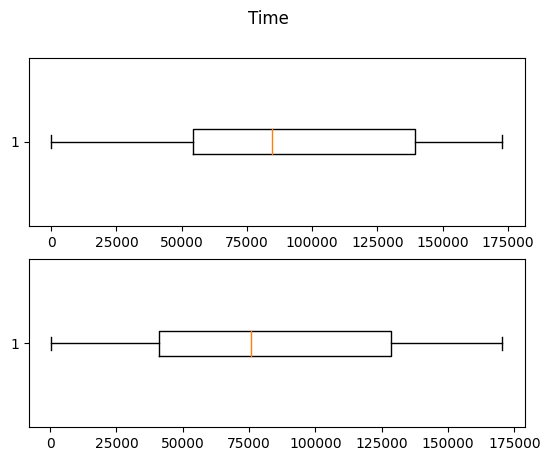

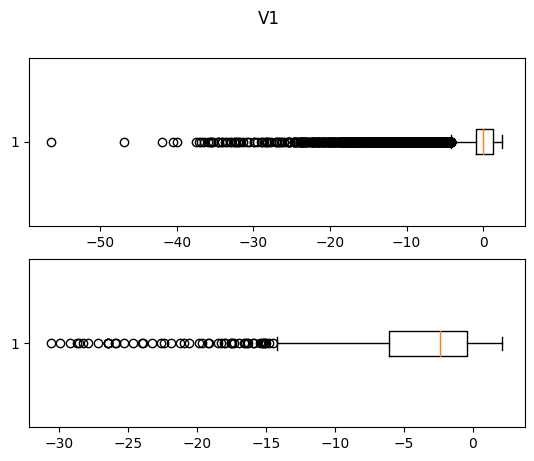

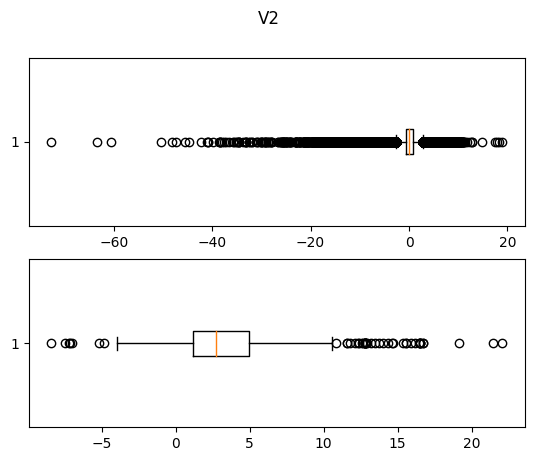

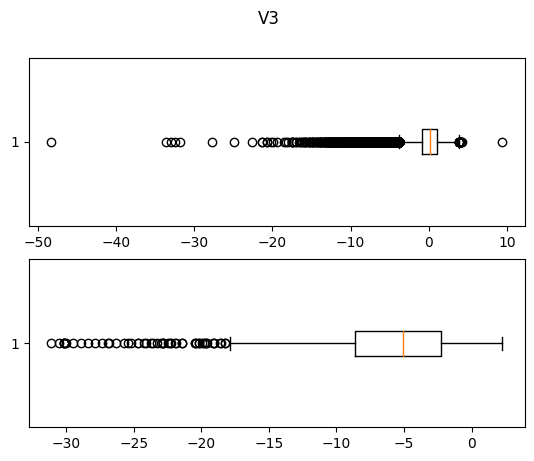

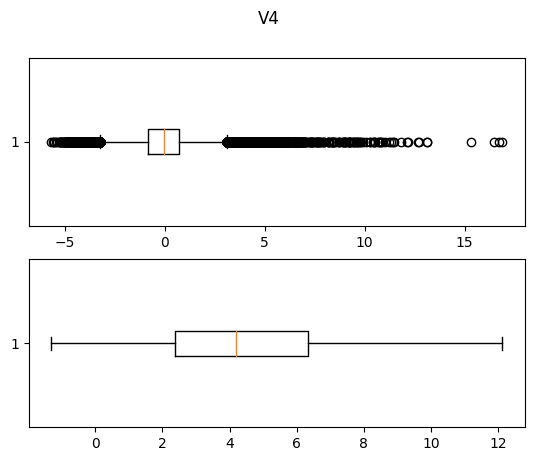

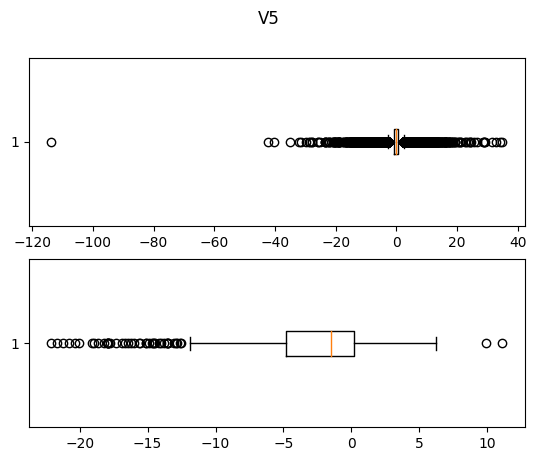

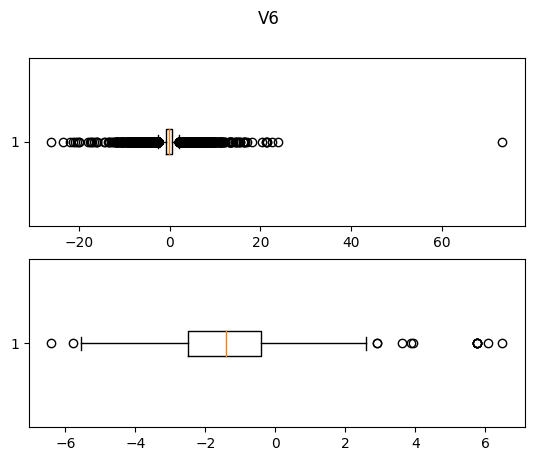

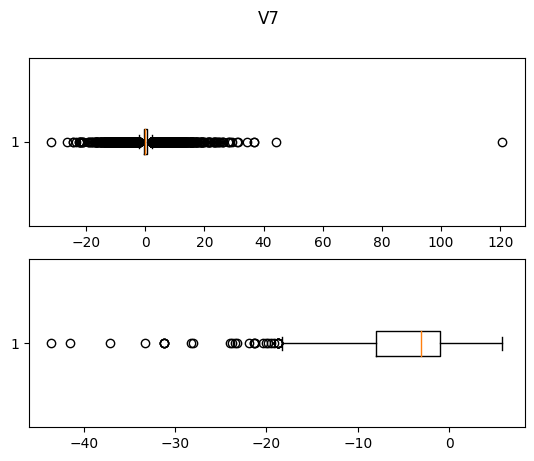

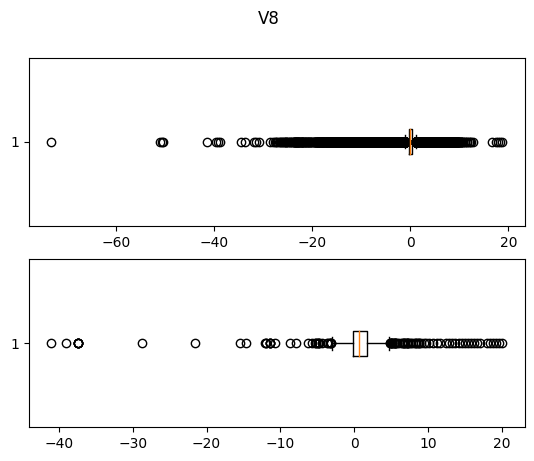

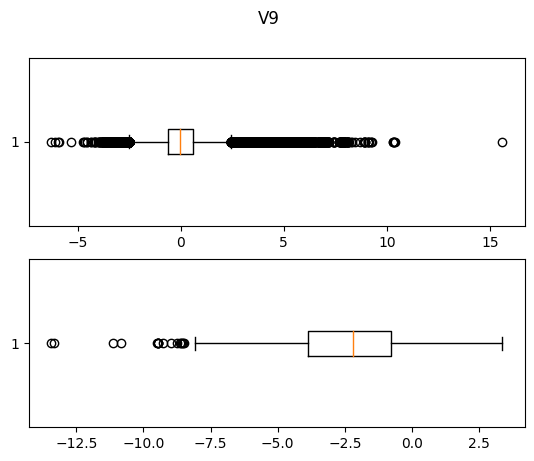

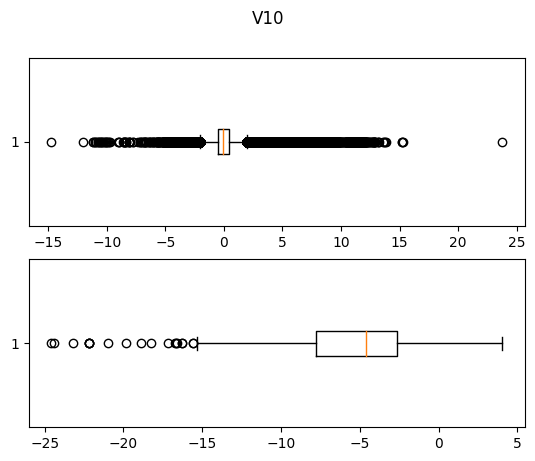

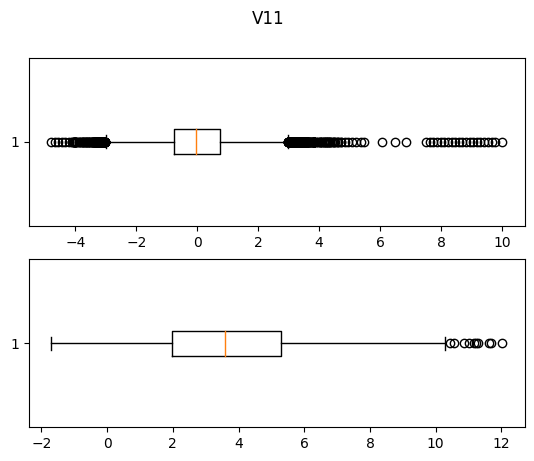

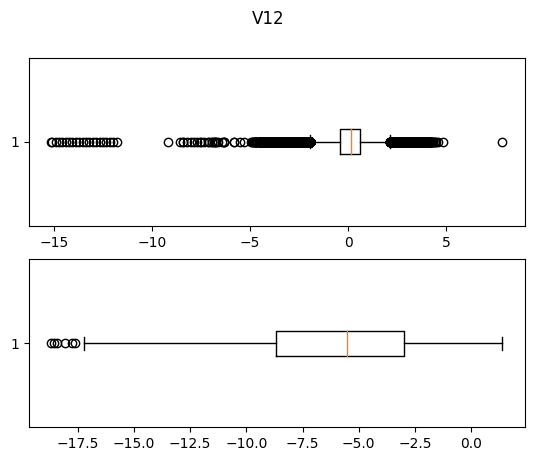

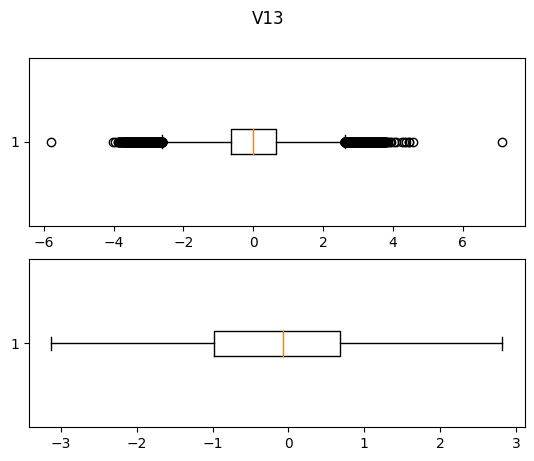

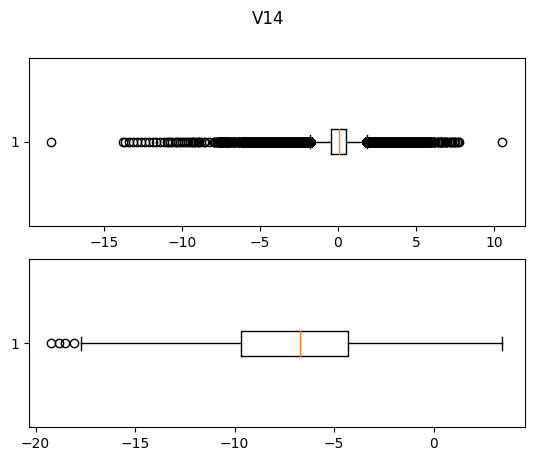

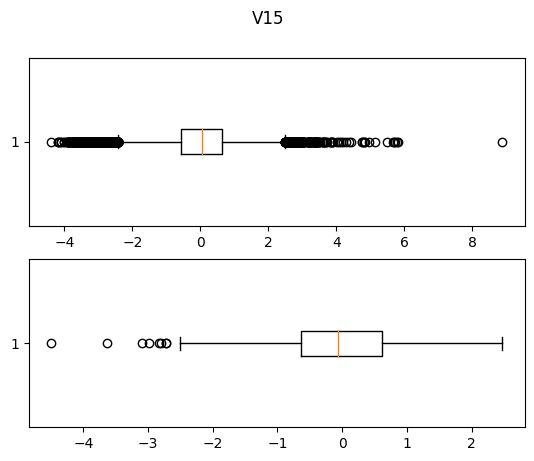

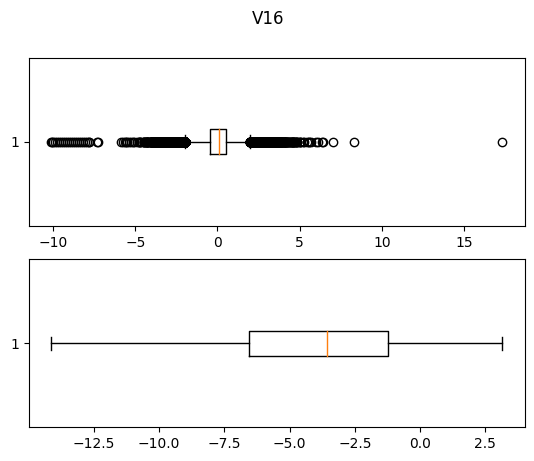

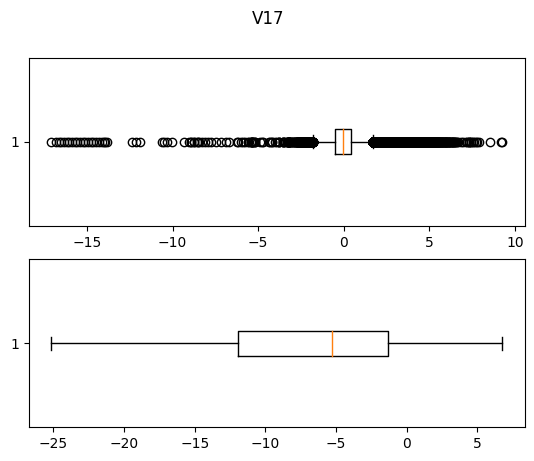

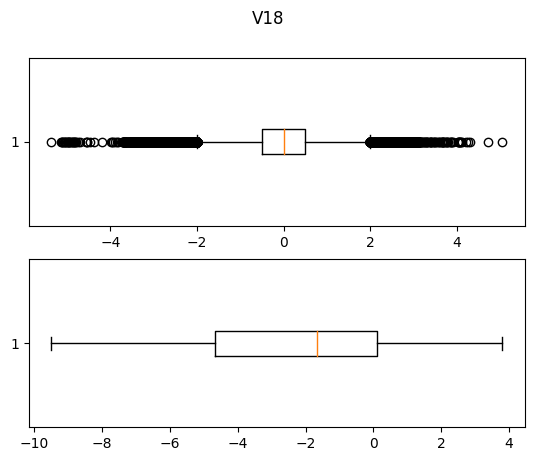

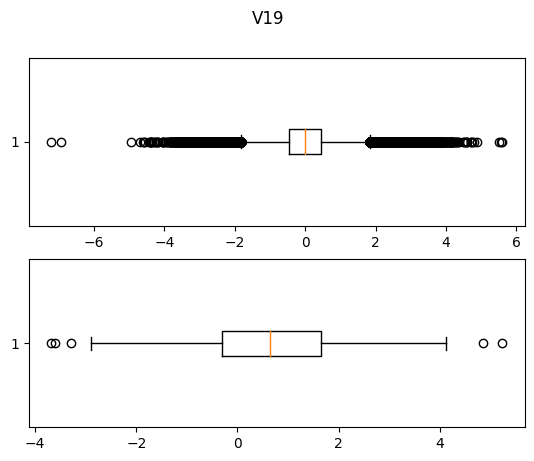

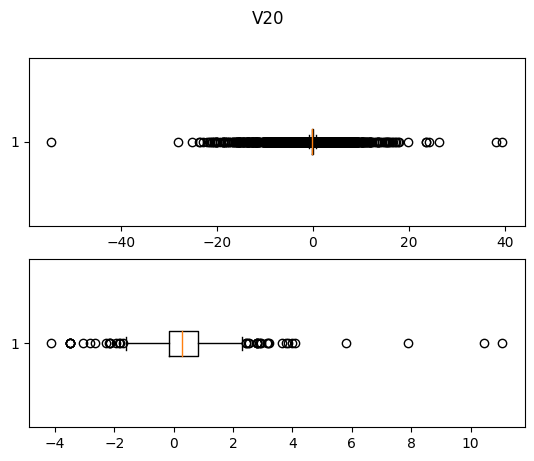

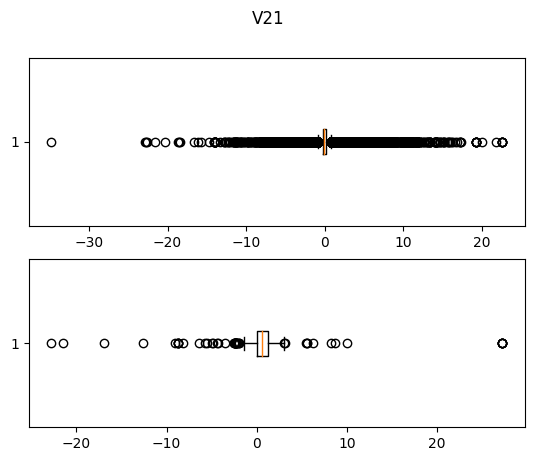

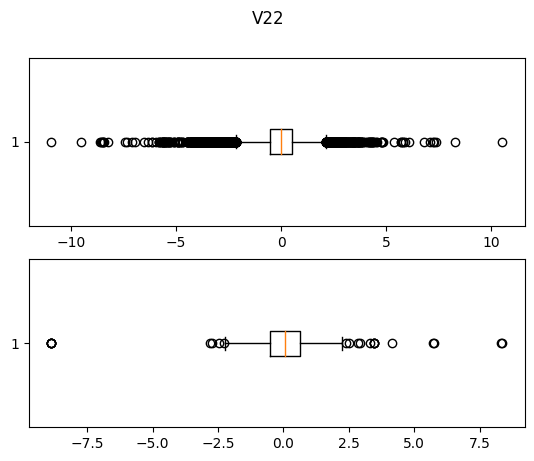

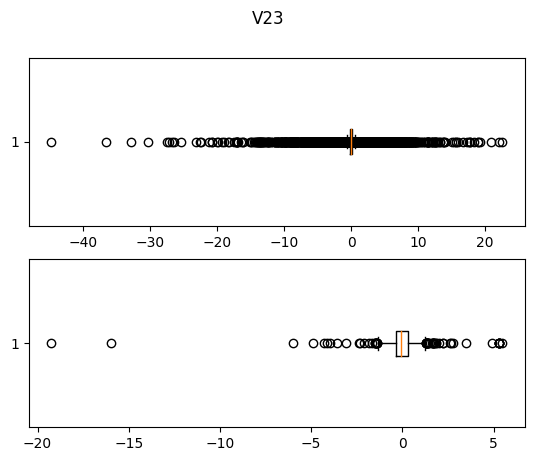

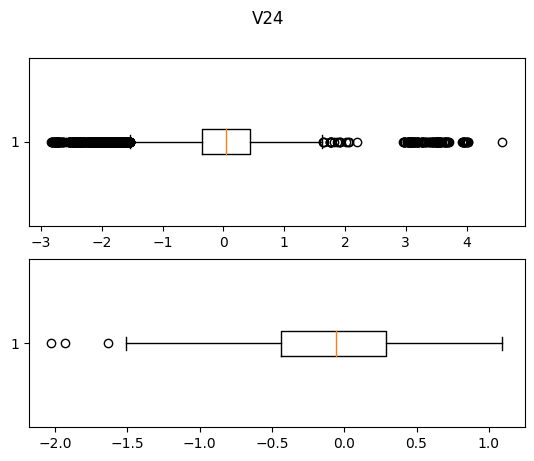

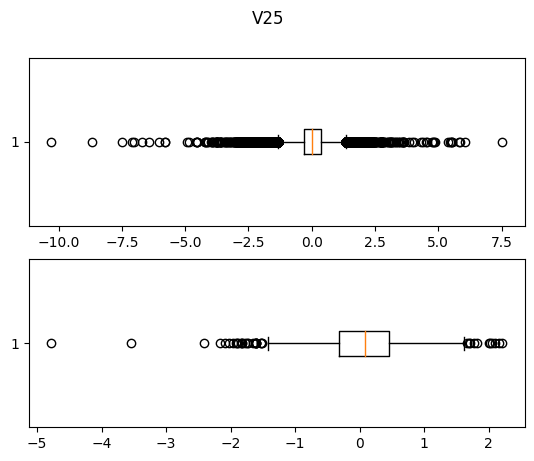

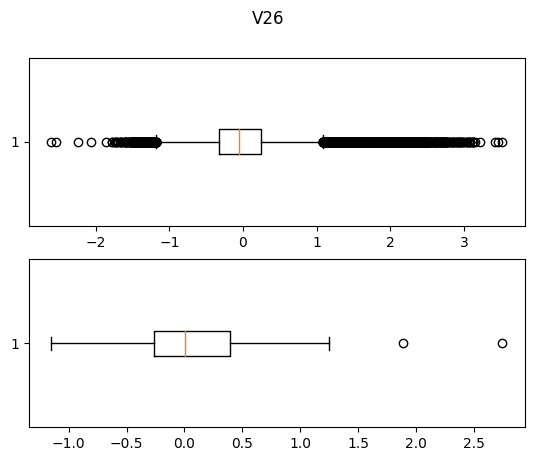

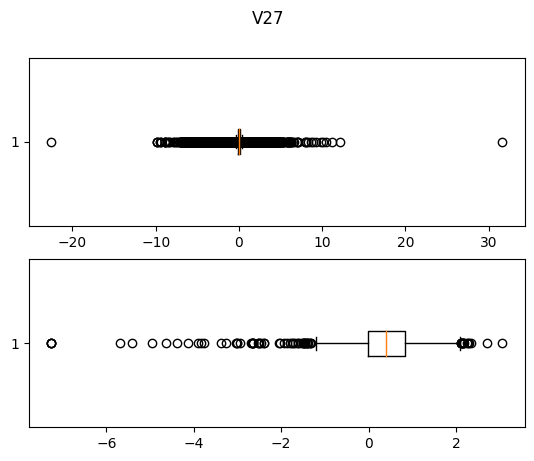

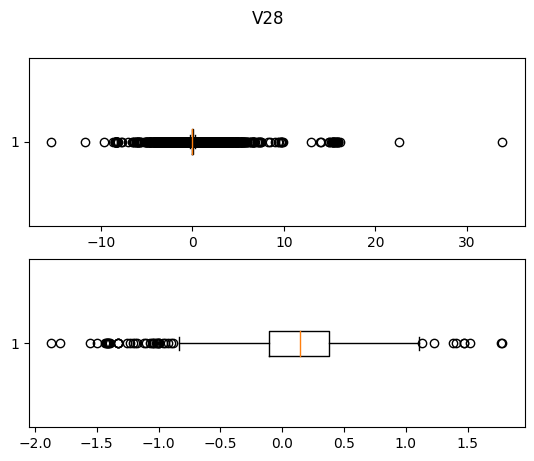

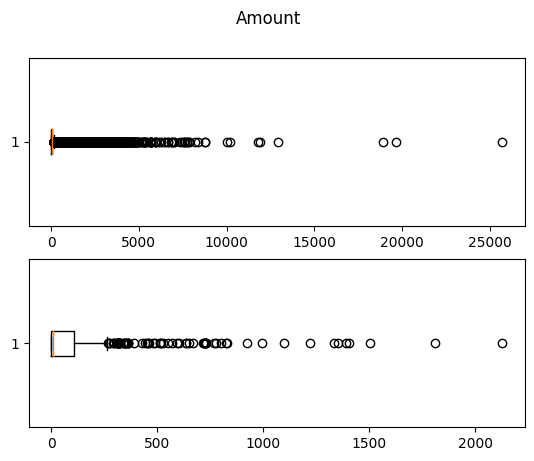

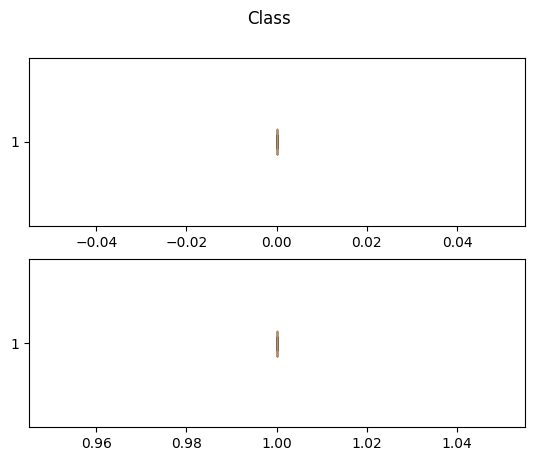

In [182]:
for i in list(df.columns):
#     fig, ax = plt.subplots(ncols=2)
#     plt.title(i)
#     sns.boxplot(data = df[i], orient="h")
#     sns.boxplot(data = df[i][df['Class'] == 1].values, orient="h")
    fig, (ax1, ax2) = plt.subplots(2)
    fig.suptitle(i)
    ax1.boxplot(x = df[i][df['Class'] == 0].values,vert = False)
    ax2.boxplot(x = df[i][df['Class'] == 1].values,vert = False)



In [183]:
# As i see on plots, visually i can't separate fraud operations and legit. May be it's because the data was PCA transformated...

In [184]:
# pdp.ProfileReport(df)

0    284315
1       492
Name: Class, dtype: int64


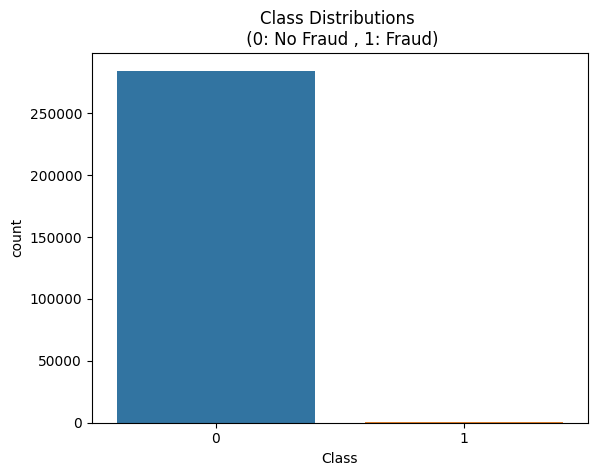

In [185]:
#class balance

print(df['Class'].value_counts())


sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud , 1: Fraud)');

 - Here we have a highly unbalanced data
 - Also it was mentioned that as data PCA transformated it could already been scaled (speaking of 'V' features)
 - Amount and Time are not scaled

 What to do?

 - First i want to make a subset of balanced data. 

In [186]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df['s_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['s_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [187]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,s_Amount,s_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


In [188]:
# dropping duplicates

df.drop_duplicates(inplace=True)

df['Class'].value_counts()

0    283253
1       473
Name: Class, dtype: int64

- We have lost some rows in class '1' but since they are duplicates i think they have no value for the training

### Making a subset

In [221]:
# making a subset

# shuffling data

df = df.sample(frac=1)

# amount of fraud classes 473 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:473]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# shuffle dataframe rows
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,s_Amount,s_Time
149600,-5.100256,3.633442,-3.843919,0.183208,-1.183997,1.602139,-3.005953,-8.645038,1.285458,-3.717481,...,-2.797150,1.090707,-0.159260,0.532156,-0.497126,0.943622,0.553581,1,3.342695,0.080617
152295,-17.537592,12.352519,-20.134613,11.122771,-14.571080,-0.381622,-23.928661,-4.724921,-8.603038,-15.231833,...,2.389041,2.019128,0.627192,-1.085997,-0.071803,-3.838198,-0.802564,1,-0.170195,0.147358
27171,-0.200370,0.206290,0.722345,-1.245920,0.326383,-0.797673,0.577152,-0.237650,-1.722546,0.244135,...,1.076588,-0.203919,0.169454,-0.247591,-0.178462,-0.030644,-0.069282,0,-0.028645,-0.590573
151006,-26.457745,16.497472,-30.177317,8.904157,-17.892600,-1.227904,-31.197329,-11.438920,-9.462573,-22.187089,...,3.460893,0.896538,0.254836,-0.738097,-0.966564,-7.263482,-1.324884,1,-0.293440,0.113606
52584,-1.519244,2.308492,-1.503599,2.064101,-1.000845,-1.016897,-2.059731,-0.275166,-1.562206,-2.755797,...,0.102826,-0.017746,0.149696,-0.096602,-0.369115,-0.019244,-0.208319,1,-0.293440,-0.459956


1    473
0    473
Name: Class, dtype: int64


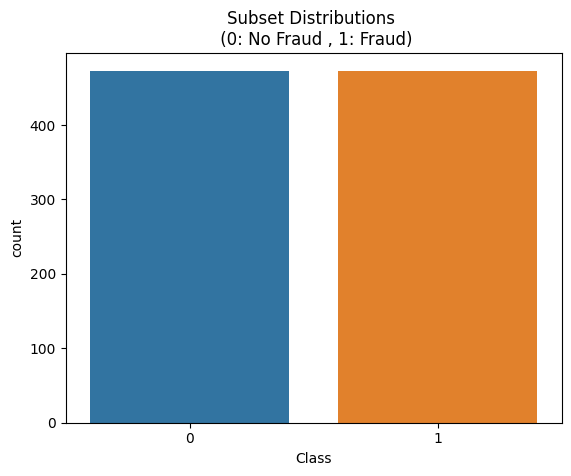

In [222]:
#subset class balance
print(new_df['Class'].value_counts())

sns.countplot(x='Class', data=new_df);
plt.title('Subset Distributions \n (0: No Fraud , 1: Fraud)');

### EDA. Correlation

<AxesSubplot:>

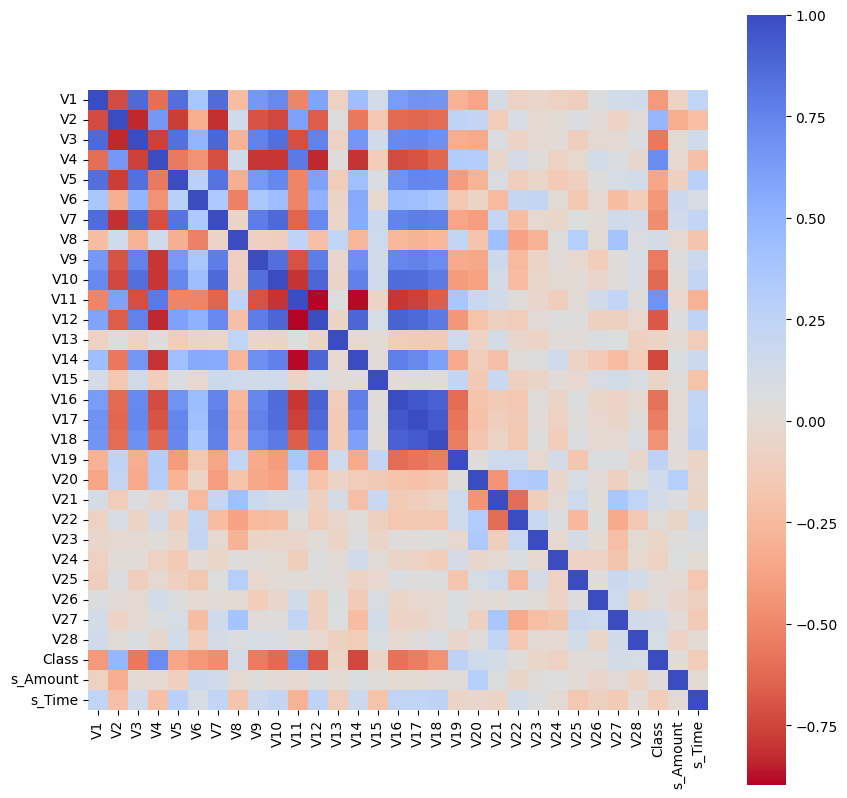

In [223]:
new_df_corr = new_df.corr()

plt.subplots(figsize=(10,10))
sns.heatmap(new_df_corr,square=True,cmap='coolwarm_r')

In [224]:
d_corr = {}

for c in list(new_df.columns):
    # print(c)
    # print(np.corrcoef(x=new_df[c],y=new_df['Class'])[0][1])
    d_corr[c] = np.corrcoef(x=new_df[c],y=new_df['Class'])[0][1]
# print(d_corr)

listOfhighposcorr = [key  for (key, value) in d_corr.items() if value >0.6 and key != 'Class']
listOfhighnegcorr = [key  for (key, value) in d_corr.items() if value <-0.6]
print('Correlation of V - features to Class')
print('High positive correlation features',listOfhighposcorr)
print('High negative correlation features',listOfhighnegcorr)

Correlation of V - features to Class
High positive correlation features ['V4', 'V11']
High negative correlation features ['V10', 'V12', 'V14']


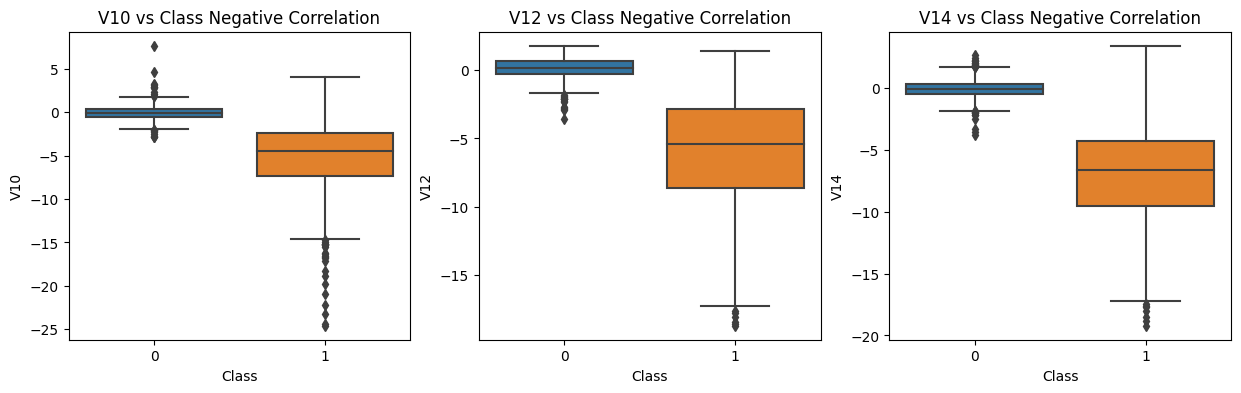

In [225]:
f, axes = plt.subplots(ncols=3, figsize=(15,4))

sns.boxplot(x="Class", y="V10", data=new_df, ax=axes[0])
axes[0].set_title('V10 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=new_df, ax=axes[1])
axes[1].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=new_df, ax=axes[2])
axes[2].set_title('V14 vs Class Negative Correlation');

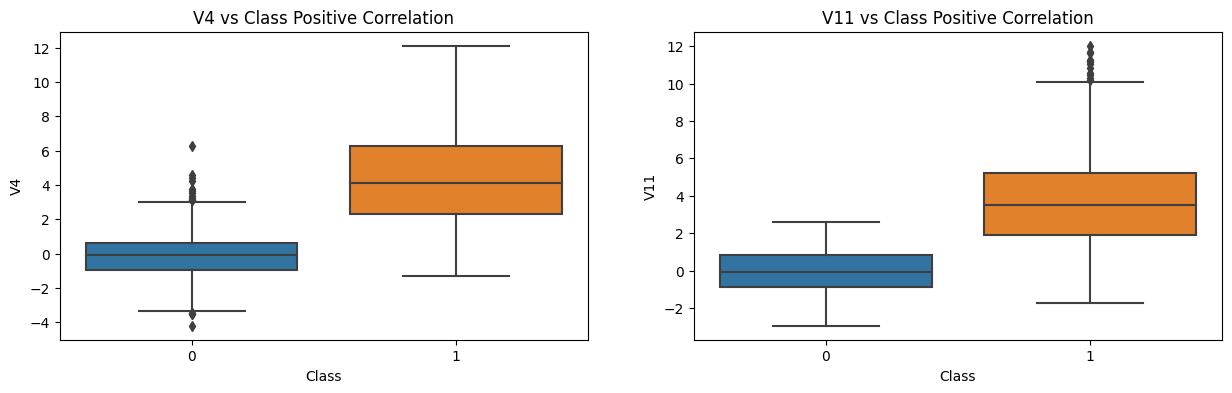

In [226]:
f, axes = plt.subplots(ncols=2, figsize=(15,4))

sns.boxplot(x="Class", y="V4", data=new_df, ax=axes[0])
axes[0].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V11", data=new_df, ax=axes[1])
axes[1].set_title('V11 vs Class Positive Correlation');


High correlation shows which features have high influence on our classification.
It's good to remove outliers of such features. 

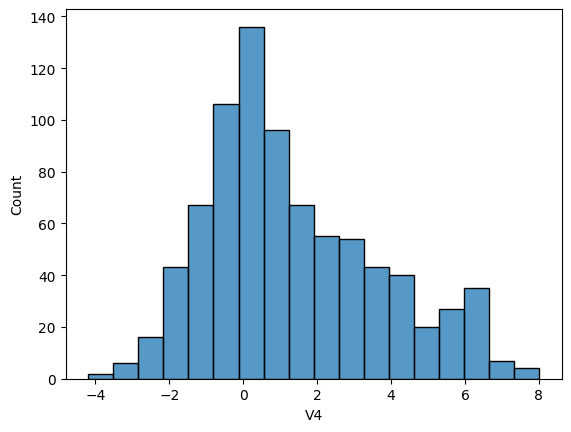

In [237]:
sns.histplot(new_df['V4']);

In [227]:
k = 3 # supposing features are distributed "normally" i'll use the rule of three sigma to cut the outliers
print(f'Shape before deleting outliers',new_df.shape)
for f in listOfhighposcorr:
    new_df = new_df.drop(new_df[(new_df[f] > new_df[f].std()*k) | (new_df[f] < -new_df[f].std()*k)].index)
for f in listOfhighnegcorr:
    new_df = new_df.drop(new_df[(new_df[f] > new_df[f].std()*k) | (new_df[f] < -new_df[f].std()*k)].index)
print(f'Shape after deleting outliers',new_df.shape)

Shape before deleting outliers (946, 31)
Shape after deleting outliers (824, 31)


### Splitting data

In [228]:
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [229]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [230]:
#Converting from df to np array
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

### Predicting

In [231]:
# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [232]:
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score

In [233]:
clfs = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier()
}

In [234]:
for key, classifier in clfs.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifiers:  LogisticRegression Has a training score of 93.0 % accuracy score
Classifiers:  KNeighborsClassifier Has a training score of 94.0 % accuracy score
Classifiers:  SVC Has a training score of 94.0 % accuracy score
Classifiers:  DecisionTreeClassifier Has a training score of 90.0 % accuracy score
Classifiers:  RandomForestClassifier Has a training score of 95.0 % accuracy score


Summary:

We get a 95% accuracy RandomForestClassifier model out of the box on a training sets. Seems promising.

In [241]:
from sklearn.metrics import classification_report

clf = LogisticRegression()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

report = classification_report(y_test, y_pred, target_names=['Non-fraud op', 'Fraud op'])
print(report)

              precision    recall  f1-score   support

Non-fraud op       0.89      0.97      0.92        89
    Fraud op       0.96      0.86      0.90        76

    accuracy                           0.92       165
   macro avg       0.92      0.91      0.91       165
weighted avg       0.92      0.92      0.91       165

